## Invoices

### Consultar Invoices

In [4]:
from invoices_management import get

vendor = 'estudio_amelia'
customer = '' # - todos
invoicing = '' # 'YYYY-MM-DD' ou ''
due = '2026-09-10' # 'YYYY-MM-DD' ou ''
payment = '' # 'YYYY-MM-DD' ou '' ou 'null' ou 'not null' - para os casos em que a fatura ainda não foi paga
email_sent = '' # 'YYYY-MM-DD' ou '' ou 'null' ou 'not null' - para os casos em que a fatura ainda não foi enviada por email
whatsapp_sent = '' # 'YYYY-MM-DD' ou '' ou 'null' ou 'not null' - para os casos em que a fatura ainda não foi enviada por whatsapp
email_receipt = '' # 'YYYY-MM-DD' ou '' ou 'null' ou 'not null' - para os casos em que a fatura ainda não foi recebida por email
whatsapp_receipt = '' # 'YYYY-MM-DD' ou '' ou 'null' ou 'not null' - para os casos em que a fatura ainda não foi recebida por whatsapp
tax = '' # 'YYYY-MM-DD' ou '' ou 'null' ou 'not null' - para os casos em que a fatura ainda não foi enviada para a contabilidade
cancellation = 'null' # 'YYYY-MM-DD' ou '' ou 'null' ou 'not null' - para os casos em que a fatura ainda não foi cancelada

invoices, qtty, total_amount, paid_amount = get(vendor, customer, invoicing, due, payment, email_sent, whatsapp_sent, email_receipt, whatsapp_receipt, tax, cancellation)
print(invoices)
print(f'Number of invoices: {qtty}')
print(f'Total amount: {total_amount}')
print(f'Paid amount: {paid_amount}')

+------+-------------+----------+-------------+------------+-----------+--------------+-----------------+-----------------+--------------------+-------+----------------+---------+------------------------------------------------------------------------+
|   id | customer    |   amount | invoicing   | due        | payment   | email_sent   | whatsapp_sent   | email_receipt   | whatsapp_receipt   | tax   | cancellation   | notes   | items                                                                  |
+======+=============+==========+=============+============+===========+==============+=================+=================+====================+=======+================+=========+========================================================================+
|  623 | miriam      |      220 | 2026-09-04  | 2026-09-10 | -         | -            | -               | -               | -                  | -     | -              | -       | aulas de canto de 60 minutos em agosto de 2026 (qtty: 2, pric

### Vencidas

In [4]:
from invoices_management import get_overdue

vendor = 'estudio_amelia'
overdue_invoices, qtty, total_amount, paid_amount = get_overdue(vendor)
print(overdue_invoices)
print(f"Quantity: {qtty}, Total Amount: {total_amount}, Paid Amount: {paid_amount}")

+------+---------------+----------+-------------+---------------------+-----------+--------------+-----------------+-----------------+--------------------+-------+----------------+---------+---------------------------------------------------------------------------------------+-----------+
|   id | customer      |   amount | invoicing   | due                 | payment   | email_sent   | whatsapp_sent   | email_receipt   | whatsapp_receipt   | tax   | cancellation   | notes   | items                                                                                 | overdue   |
+======+===============+==========+=============+=====================+===========+==============+=================+=================+====================+=======+================+=========+=======================================================================================+===========+
|  614 | andressa_lino |       70 | 2026-08-20  | 2026-08-27 00:00:00 | -         | 2026-08-20   | -               | -         

### Faturamento

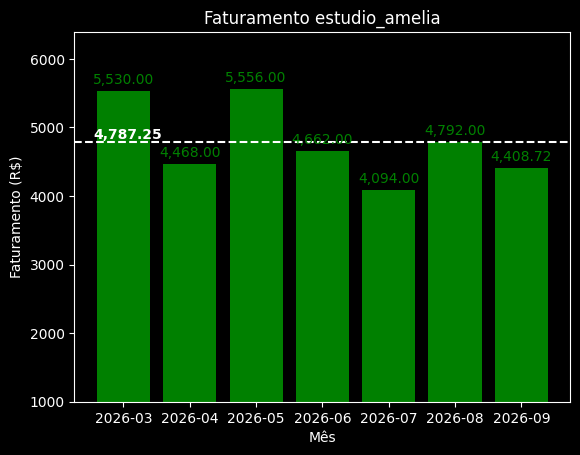

In [15]:
from invoices_management import invoicing_graph

vendor = 'estudio_amelia'
inicio = '2026-01-01'
fim = '2026-12-31'

plt = invoicing_graph(vendor, inicio, fim)


### Inserir invoice

In [8]:
from invoices_management import insert

vendor = 'estudio_amelia'
customer = 'nicolas_neri' #
invoicing = '2026-09-08' # 'YYYY-MM-DD'
due = '2026-09-08' # 'YYYY-MM-DD'
payment = '' # 'YYYY-MM-DD' ou ''
cancellation = '' # 'YYYY-MM-DD' ou ''
notes = '' # 'texto' ou ''

items = [
    {'description': 'aulas de canto de 30 minutos em setembro de 2026', 'quantity': 4, 'price': 70},
    {'description': 'adicional taxa paypal para aulas de setembro de 2026', 'quantity': 1, 'price': 14.72}
]
invoices = insert(vendor, customer, invoicing, due, payment, cancellation, notes, items)
print(invoices)


success - Invoice created successfully


### Registrar pagamento

In [1]:
from invoices_management import get_paid

vendor = 'estudio_amelia'
customer = 'nicolas_neri' #
invoicing = '2026-09' # 'YYYY-MM-DD' ou ''
payment_date = '2026-09-08'
payment_value = 280.00

resp = get_paid(vendor, customer, invoicing, payment_value, payment_date)
print(resp)


Pagamento registrado e enviado com sucesso.


### Alterar invoice

In [ ]:
from invoices_management import update

vendor = 'estudio_amelia' # coloque o nome do fornecedor que deseja atualizar a fatura
id = 630    # coloque o id da fatura que deseja atualizar
invoicing = '' # 'YYYY-MM-DD' ou ''
due = '' # 'YYYY-MM-DD' ou ''
payment = '2026-09' # 'YYYY-MM-DD' ou ''
email_sent = '' # 'YYYY-MM-DD' ou ''
whatsapp_sent = '' # 'YYYY-MM-DD' ou ''
cancellation = '' # 'YYYY-MM-DD' ou ''
tax = '' # 'YYYY-MM-DD' ou ''

invoices = update(vendor, id, invoicing, due, payment, email_sent, whatsapp_sent, tax, cancellation)
print(invoices)


success - Invoice updated successfully


### Send Bill

In [6]:
from invoices_management import send_bill

vendor = 'estudio_amelia'
invoice_id = 624
doc = 0 # 0 - invoice, 1 - recibo
email = ''

result = send_bill(vendor, invoice_id, doc, email)
print(result)

success - 


### Save Bill

In [12]:
from invoices_management import save_bill

vendor = 'estudio_amelia'
invoice_id = 631
doc = 0
path = '../files/'

result = save_bill(vendor, invoice_id, doc, path)
print(result)

Arquivo salvo com sucesso em: ../files/2026-09-08-2026-09-08-nicolas_neri-invoice.pdf


### Insert CSV

In [8]:
from invoices_management import insert_csv

vendor = 'estudio_amelia'
csv_file = '../files/invoices-2026-09.csv'

responses = insert_csv(vendor, csv_file)    
for line, text in enumerate(responses, start=1):
    print(f'{line} - {text}')
print(f'Total: {len(responses)}')

1 - Payload '{'vendor': 'estudio_amelia', 'customer': 'ana_flavia', 'invoicing': '2026-09-04', 'due': '2026-09-07', 'payment': '', 'cancellation': '', 'notes': '', 'items': [{'description': 'aulas de canto de 60 minutos em agosto de 2026', 'quantity': 2, 'price': 110.0}]}'.Resposta: success - Invoice created successfully
2 - Payload '{'vendor': 'estudio_amelia', 'customer': 'camila_merigui', 'invoicing': '2026-09-04', 'due': '2026-09-07', 'payment': '', 'cancellation': '', 'notes': '', 'items': [{'description': 'aulas de canto de 60 minutos em agosto de 2026', 'quantity': 3, 'price': 98.0}, {'description': 'aulas de piano de 60 minutos em agosto de 2026', 'quantity': 2, 'price': 98.0}]}'.Resposta: success - Invoice created successfully
3 - Payload '{'vendor': 'estudio_amelia', 'customer': 'carol_teclarte', 'invoicing': '2026-09-04', 'due': '2026-09-07', 'payment': '', 'cancellation': '', 'notes': '', 'items': [{'description': 'aulas de canto de 45 minutos em setembro de 2026', 'quantit